# 4) Decision tree

- Type of model: SUPERVISED
- Model type of approach: self-finding heuristic

In [27]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GroupKFold

PROC_DIR = Path("./../artifacts")
FIG_DIR = Path("./../figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())
y = (df["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth
N_FOLDS = sel["n_folds"]

print(f"{len(df)} windows, {df['recording_id'].nunique()} recordings, {df['participant'].nunique()} participants")
print(f"{len(sel['kept'])} features kept by the filters, {len(sel['all'])} candidates")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "orange", "smooth": "blue"}
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

N_FOLDS = sel["n_folds"]
ALL = sel["all"]

# split iterators: lists of (train_mask, test_mask) over windows
SPLITS = {
    "grouped folds": [((df["fold"] != k).to_numpy(), (df["fold"] == k).to_numpy()) for k in range(N_FOLDS)],
    "leave-one-participant-out": [((df["participant"] != p).to_numpy(), (df["participant"] == p).to_numpy())
                                  for p in sorted(df["participant"].unique())],
}

768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 4.1 A tree on two features

Same two features as in k-means notebook, that were dominant 

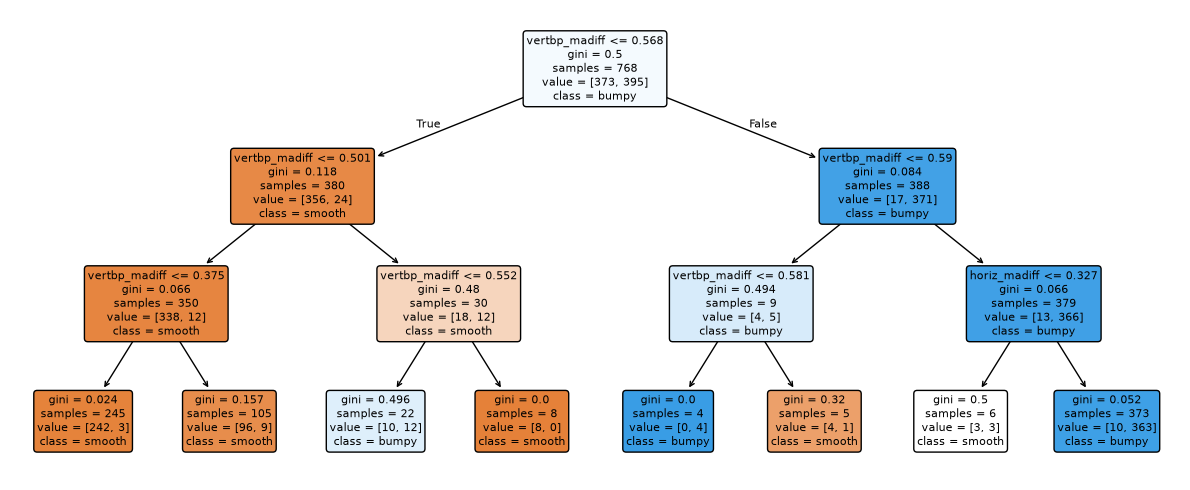

|--- vertbp_madiff <= 0.568
|   |--- vertbp_madiff <= 0.501
|   |   |--- vertbp_madiff <= 0.375
|   |   |   |--- class: smooth
|   |   |--- vertbp_madiff >  0.375
|   |   |   |--- class: smooth
|   |--- vertbp_madiff >  0.501
|   |   |--- vertbp_madiff <= 0.552
|   |   |   |--- class: bumpy
|   |   |--- vertbp_madiff >  0.552
|   |   |   |--- class: smooth
|--- vertbp_madiff >  0.568
|   |--- vertbp_madiff <= 0.590
|   |   |--- vertbp_madiff <= 0.581
|   |   |   |--- class: bumpy
|   |   |--- vertbp_madiff >  0.581
|   |   |   |--- class: smooth
|   |--- vertbp_madiff >  0.590
|   |   |--- horiz_madiff <= 0.327
|   |   |   |--- class: smooth
|   |   |--- horiz_madiff >  0.327
|   |   |   |--- class: bumpy



In [28]:
feats2 = ["vertbp_madiff", "horiz_madiff"]
tree2 = DecisionTreeClassifier(max_depth=3, random_state=0).fit(df[feats2], y)

fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(tree2, feature_names=feats2, class_names=["smooth", "bumpy"], 
          filled=True, rounded=True,
          impurity=True, proportion=False, fontsize=8, ax=ax)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_2d_rules.png", dpi=120, bbox_inches="tight"); plt.show()

print(export_text(tree2, feature_names=feats2, class_names=["smooth", "bumpy"], decimals=3))

Every split is a horizontal or vertical line, so the decision regions are rectangles. 

Different compared with k-means, whose boundary was one diagonal line between two centroids.

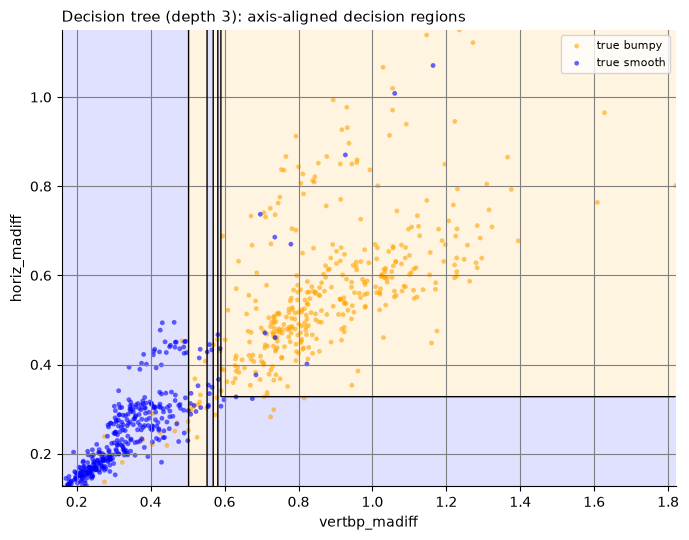

In [29]:
x0, x1 = df[feats2[0]].to_numpy(), df[feats2[1]].to_numpy()
g0, g1 = np.meshgrid(np.linspace(x0.min(), x0.max(), 400), np.linspace(x1.min(), x1.max(), 400))
grid = tree2.predict(pd.DataFrame(np.c_[g0.ravel(), g1.ravel()], columns=feats2)).reshape(g0.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(g0, g1, grid, levels=[-0.5, 0.5, 1.5], alpha=0.12, colors=[CLASS_COLOR["smooth"], CLASS_COLOR["bumpy"]])
ax.contour(g0, g1, grid, levels=[0.5], colors="black", linewidths=1)

for lab in CLASSES:
    m = (df["label"] == lab).to_numpy()
    ax.scatter(x0[m], x1[m], s=12, alpha=0.6, color=CLASS_COLOR[lab], edgecolors="none", label=f"true {lab}")
    
ax.set(xlabel=feats2[0], ylabel=feats2[1])
ax.set_title("Decision tree (depth 3): axis-aligned decision regions", loc="left", fontsize=11)
ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_2d_regions.png", dpi=120, bbox_inches="tight"); plt.show()

## 4.2 Depth vs Accuracy Analysis

The deeper the tree, the more rectangles it can draw. 

Training accuracy always goes up with depth, but on unseen recordings it stops improving (or drops) once the tree starts fitting individual windows. 

This is the bias–variance trade-off in one plot, to find optimal of generalization.

Here the tree gets **all 66 features**. 
`max_depth=None` means the tree is grown until every leaf is pure.

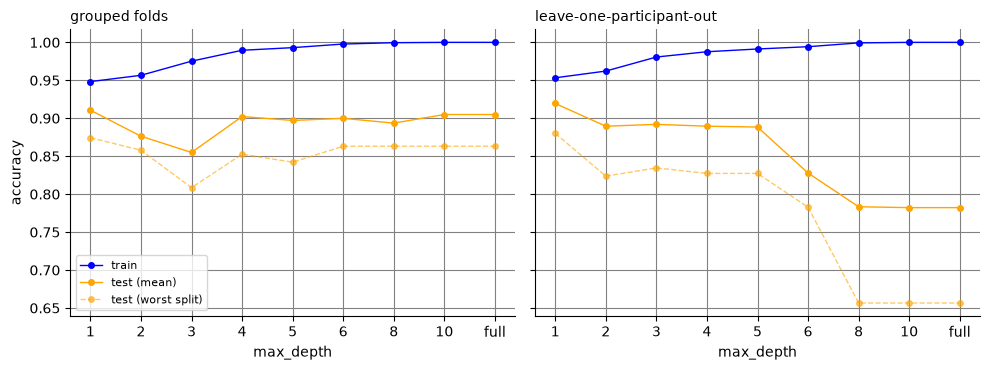

split,grouped folds,leave-one-participant-out
depth,,
1,0.911,0.919
2,0.876,0.890
3,0.855,0.892
4,0.902,0.890
5,0.897,0.888
6,0.900,0.828
8,0.894,0.783
10,0.905,0.782
full,0.905,0.782


In [30]:
DEPTHS = [1, 2, 3, 4, 5, 6, 8, 10, None]

def cv_accuracy(splits, feats, **params):
    tr_acc, te_acc = [], []
    for tr, te in splits:
        clf = DecisionTreeClassifier(random_state=0, **params).fit(df.loc[tr, feats], y[tr])
        tr_acc.append(clf.score(df.loc[tr, feats], y[tr]))
        te_acc.append(clf.score(df.loc[te, feats], y[te]))
        
    return np.mean(tr_acc), np.mean(te_acc), np.min(te_acc)

rows = [{"split": s, "depth": "full" if d is None else d, 
         **dict(zip(["train", "test", "worst test"], cv_accuracy(SPLITS[s], ALL, max_depth=d)))}
        for s in SPLITS for d in DEPTHS]
depth_curve = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (s, d) in zip(axes, depth_curve.groupby("split", sort=False)):
    xs = range(len(d))
    ax.plot(xs, d["train"], marker="o", markersize=4, color=PALETTE[0], label="train")
    ax.plot(xs, d["test"], marker="o", markersize=4, color=PALETTE[1], label="test (mean)")
    ax.plot(xs, d["worst test"], marker="o", markersize=4, color=PALETTE[1], linestyle="--", alpha=0.6, label="test (worst split)")
    ax.set_xticks(xs, d["depth"]); ax.set(xlabel="max_depth")
    ax.set_title(s, loc="left", fontsize=10)
    
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "tree_depth_curve.png", dpi=120, bbox_inches="tight"); plt.show()

depth_curve.pivot(index="depth", columns="split", values="test").reindex(["full" if d is None else d for d in DEPTHS]).round(3)

## 4.3 Decision Tree feature break-down

Earlier we have explored by Fisher score the ranking, but here the decision tree choose itself the optimal features based on the training.

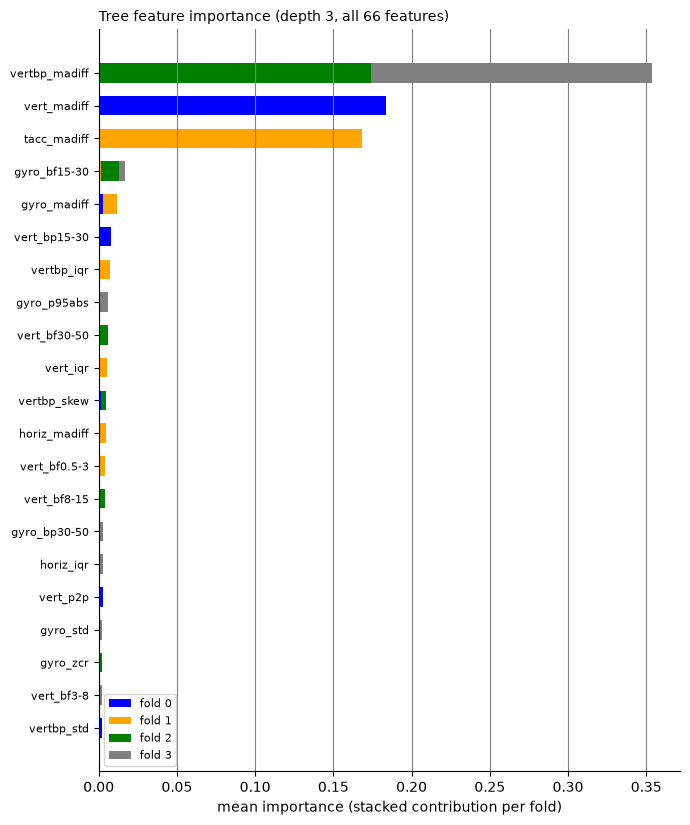

,fold 0,fold 1,fold 2,fold 3,mean,folds used,Fisher rank
vertbp_madiff,0.000,0.000,0.870,0.899,0.442,2,1
vert_madiff,0.918,0.000,0.000,0.000,0.229,1,removed by filter
tacc_madiff,0.000,0.842,0.000,0.000,0.211,1,removed by filter
gyro_bf15-30,0.000,0.007,0.057,0.021,0.021,3,25
gyro_madiff,0.013,0.045,0.000,0.000,0.014,2,23
vert_bp15-30,0.040,0.000,0.000,0.000,0.010,1,16
vertbp_iqr,0.000,0.037,0.000,0.000,0.009,1,2
gyro_p95abs,0.000,0.000,0.000,0.031,0.008,1,48
vert_bf30-50,0.000,0.000,0.029,0.000,0.007,1,50
vert_iqr,0.000,0.026,0.000,0.000,0.007,1,10


In [31]:
DEPTH_SHOW = 3

imp = pd.DataFrame({f"fold {k}": 
    DecisionTreeClassifier(max_depth=DEPTH_SHOW, random_state=0).fit(df.loc[tr, ALL], y[tr]).feature_importances_
                    for k, (tr, _) in enumerate(SPLITS["grouped folds"])}, index=ALL)

imp = imp.loc[(imp > 0).any(axis=1)]
imp["mean"] = imp.mean(axis=1)
imp["folds used"] = (imp.drop(columns="mean") > 0).sum(axis=1)
imp["Fisher rank"] = [sel["ranked_by_fisher"].index(f) + 1 if f in sel["ranked_by_fisher"] else "removed by filter" for f in imp.index]
imp = imp.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(imp) + 1))
fold_cols = [c for c in imp.columns if c.startswith("fold")]
left = np.zeros(len(imp))

for c, color in zip(fold_cols, ["blue", "orange", "green", "gray"]):
    ax.barh(range(len(imp))[::-1], imp[c] / len(fold_cols), left=left, color=color, height=0.6, label=c)
    left += imp[c].to_numpy() / len(fold_cols)
    
ax.set_yticks(range(len(imp))[::-1], imp.index, fontsize=8)
ax.set_xlabel("mean importance (stacked contribution per fold)")
ax.set_title(f"Tree feature importance (depth {DEPTH_SHOW}, all {len(ALL)} features)", loc="left", fontsize=10)
ax.grid(axis="y", visible=False); ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_importance.png", dpi=120, bbox_inches="tight"); plt.show()

imp.round(3)

## 4.4 Cross-validation

Nested CV:

- **outer loop**: leave one participant out, this participant is only used for the final score
- **inner loop**: on the remaining two participants, a grouped CV (by recording) picks `max_depth`
- the tree is then refitted on all outer-training data with the chosen depth

Compared against:
- a **depth-1 tree** ("stump"): one feature, one threshold. The tree picks the feature and threshold itself, so this is the learned version of the single-feature baseline.
- **Threshold on `vertbp_madiff`** as a sanity check

In [32]:
INNER_DEPTHS = [1, 2, 3, 4, 5, 6, 8, None]

def nested_tree(tr, te, feats):
    inner = GroupKFold(n_splits=4).split(df.loc[tr, feats], y[tr], groups=df.loc[tr, "recording_id"])
    inner = [(np.isin(np.arange(len(df)), np.flatnonzero(tr)[a]), np.isin(np.arange(len(df)), np.flatnonzero(tr)[b])) for a, b in inner]
    best = max(INNER_DEPTHS, key=lambda d: cv_accuracy(inner, feats, max_depth=d)[1])
    clf = DecisionTreeClassifier(max_depth=best, random_state=0).fit(df.loc[tr, feats], y[tr])
    return clf.predict(df.loc[te, feats]), best

def stump(tr, te, feats):
    return DecisionTreeClassifier(max_depth=1, random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def full_tree(tr, te, feats):
    return DecisionTreeClassifier(random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def threshold_baseline(tr, te, f="vertbp_madiff"):
    x = df[f].to_numpy()
    thr = (np.median(x[tr][y[tr] == 1]) + np.median(x[tr][y[tr] == 0])) / 2
    return (x[te] > thr).astype(int)

rows, chosen = [], {}
for p, (tr, te) in zip(sorted(df["participant"].unique()), SPLITS["leave-one-participant-out"]):
    pred, best = nested_tree(tr, te, ALL)
    chosen[p] = "full" if best is None else best
    for model, yhat in {"tree, depth by inner CV": pred, "stump (depth 1)": stump(tr, te, ALL),
                        "full-depth tree": full_tree(tr, te, ALL), "baseline: threshold on vertbp_madiff": threshold_baseline(tr, te)}.items():
        rows.append({"model": model, "held-out participant": p, "accuracy": (yhat == y[te]).mean()})

nested = pd.DataFrame(rows).pivot(index="model", columns="held-out participant", values="accuracy")
nested["mean"] = nested.mean(axis=1)

print("depth chosen by the inner CV per held-out participant:", chosen)
nested.sort_values("mean", ascending=False).round(3)

depth chosen by the inner CV per held-out participant: {'P01': 1, 'P02': 1, 'P03': 1}


held-out participant,P01,P02,P03,mean
model,,,,
baseline: threshold on vertbp_madiff,0.949,0.928,0.921,0.933
stump (depth 1),0.965,0.880,0.914,0.919
"tree, depth by inner CV",0.965,0.880,0.914,0.919
full-depth tree,0.657,0.866,0.824,0.782


## 4.5 Macro Evaluation: Per recording

For every recording, the fraction of its windows predicted *bumpy* by the nested-CV tree when that recording's participant was held out.

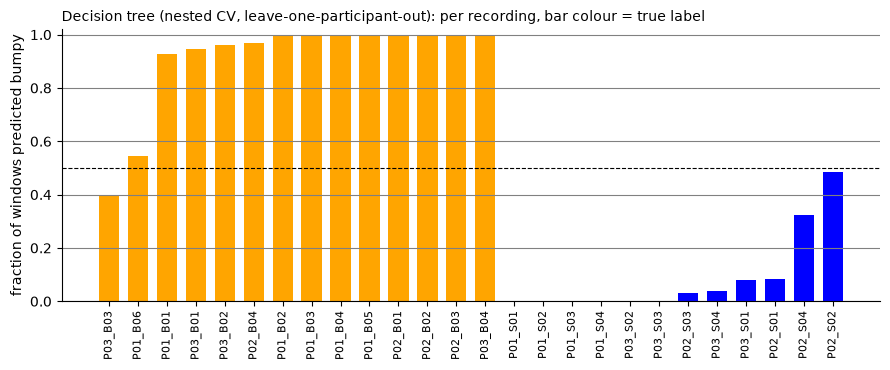

majority vote per recording: 96% of 26 recordings correct


In [33]:
pred = np.zeros(len(df), dtype=int)
for tr, te in SPLITS["leave-one-participant-out"]:
    pred[te] = nested_tree(tr, te, ALL)[0]

per_rec = (df.assign(pred_bumpy=pred).groupby("recording_id")
             .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean"), n_windows=("pred_bumpy", "size"))
             .sort_values(["label", "frac_bumpy"]))

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.bar(range(len(per_rec)), per_rec["frac_bumpy"], color=per_rec["label"].map(CLASS_COLOR), width=0.7)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(per_rec)), per_rec.index, rotation=90, fontsize=8)
ax.set(ylabel="fraction of windows predicted bumpy", ylim=(0, 1.02))
ax.set_title("Decision tree (nested CV, leave-one-participant-out): per recording, bar colour = true label", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_per_recording.png", dpi=120, bbox_inches="tight"); plt.show()

rec_acc = ((per_rec["frac_bumpy"] > 0.5) == (per_rec["label"] == "bumpy")).mean()
print(f"majority vote per recording: {rec_acc:.0%} of {len(per_rec)} recordings correct")

## 4.6 Export results

Same format as the k-means export, so the files can be concatenated into one comparison table. Saved to `artifacts/results/`:

- `tree_metrics_per_fold.csv`: one row per split, model and held-out fold / participant, with confusion counts
- `tree_metrics_summary.csv`: mean and worst fold per split and model
- `tree_predictions.csv`: out-of-fold prediction for every window

- **precision**: of the windows predicted bumpy, the fraction that really are bumpy
- **recall**: of the bumpy windows, the fraction found
- **specificity**: of the smooth windows, the fraction correctly called smooth
- **balanced accuracy**: mean of recall and specificity, not affected by class imbalance within a fold

In [34]:
from sklearn.metrics import confusion_matrix

def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    safe = lambda a, b: a / b if b else np.nan
    precision, recall, specificity = safe(tp, tp + fp), safe(tp, tp + fn), safe(tn, tn + fp)
    
    return {"n": len(y_true), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy": (tp + tn) / len(y_true), "balanced_accuracy": (recall + specificity) / 2,
            "precision": precision, "recall": recall, "specificity": specificity,
            "f1": safe(2 * precision * recall, precision + recall)}

MODELS = {
    "tree, depth by inner CV": lambda tr, te: nested_tree(tr, te, ALL)[0],
    "stump (depth 1)": lambda tr, te: stump(tr, te, ALL),
    "full-depth tree": lambda tr, te: full_tree(tr, te, ALL),
    "baseline: threshold on vertbp_madiff": threshold_baseline,
}

FOLD_NAMES = {"grouped folds": [f"fold {k}" for k in range(N_FOLDS)],
              "leave-one-participant-out": sorted(df["participant"].unique())}

metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
            yhat = predict(tr, te)
            metric_rows.append({"split": split_name, "model": model_name, "held_out": fold_name,
                                **classification_metrics(y[te], yhat)})
            pred_frames.append(df.loc[te, ["recording_id", "participant", "label"]]
                               .assign(split=split_name, model=model_name, held_out=fold_name,
                                       pred=np.where(yhat == 1, "bumpy", "smooth")))

per_fold = pd.DataFrame(metric_rows)
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "tree_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "tree_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "tree_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)

saved to D:\2-Courses\5ARE0-Project\Machine_Learning_for_rides\artifacts\results


accuracy_mean  \
split                     model                                                 
grouped folds             baseline: threshold on vertbp_madiff          0.940   
                          full-depth tree                               0.905   
                          stump (depth 1)                               0.911   
                          tree, depth by inner CV                       0.888   
leave-one-participant-out baseline: threshold on vertbp_madiff          0.933   
                          full-depth tree                               0.782   
                          stump (depth 1)                               0.919   
                          tree, depth by inner CV                       0.919   

                                                                balanced_accuracy_mean  \
split                     model                                                          
grouped folds             baseline: threshold on vertbp_madiff                   0.936   
                          full-depth tree                                        0.905   
                          stump (depth 1)                                        0.903   
                          tree, depth by inner CV                                0.879   
leave-one-participant-out baseline: threshold on vertbp_madiff                   0.938   
                          full-depth tree                                        0.804   
                          stump (depth 1)                                        0.927   
                          tree, depth by inner CV                                0.927   

                                                                precision_mean  \
split                     model                                                  
grouped folds             baseline: threshold on vertbp_madiff           0.950   
                          full-depth tree                                0.902   
                          stump (depth 1)                                0.895   
                          tree, depth by inner CV                        0.870   
leave-one-participant-out baseline: threshold on vertbp_madiff           0.946   
                          full-depth tree                                0.917   
                          stump (depth 1)                                0.921   
                          tree, depth by inner CV                        0.921   

                                                                recall_mean  \
split                     model                                               
grouped folds             baseline: threshold on vertbp_madiff        0.915   
                          full-depth tree                             0.906   
                          stump (depth 1)                             0.935   
                          tree, depth by inner CV                     0.922   
leave-one-participant-out baseline: threshold on vertbp_madiff        0.929   
                          full-depth tree                             0.694   
                          stump (depth 1)                             0.933   
                          tree, depth by inner CV                     0.933   

                                                                specificity_mean  \
split                     model                                                    
grouped folds             baseline: threshold on vertbp_madiff             0.957   
                          full-depth tree                                  0.904   
                          stump (depth 1)                                  0.872   
                          tree, depth by inner CV                          0.836   
leave-one-participant-out baseline: threshold on vertbp_madiff             0.948   
                          full-depth tree                                  0.915   
                          stump (depth 1)                           